# 1. Khởi tạo và Nạp dữ liệu

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import os

# Thiết lập đường dẫn và load dữ liệu
base_dir = os.path.dirname(os.getcwd())
train_df = pd.read_csv(os.path.join(base_dir, 'data', 'preprocessed', 'train_data.csv'))
test_df = pd.read_csv(os.path.join(base_dir, 'data', 'preprocessed', 'test_data.csv'))

print(f"Dữ liệu huấn luyện: {train_df.shape}")
print(f"Dữ liệu kiểm tra: {test_df.shape}")

Dữ liệu huấn luyện: (7292, 14)
Dữ liệu kiểm tra: (1824, 14)


# 2. Feature Engineering
Thực hiện thiết kế mô hình tích hợp các kỹ thuật:
* **Đặc trưng đa thức (Polynomial):** Thêm biến diện tích bình phương để bắt lấy quan hệ phi tuyến.
* **Biến tương tác (Spatial Interaction):** Tạo sự kết hợp giữa diện tích và từng Quận cụ thể để mô hình hóa đơn giá riêng biệt cho mỗi khu vực.
* **Chọn subsets để xử lý đa cộng tuyến:** Loại bỏ cột 'thanh_pho' vì thông tin này đã được bao hàm trong biến 'quan'. Bên cạnh đó còn có `phong_tam` và `phong_ngu` cũng tương tự, tôi chỉ giữ lại cột `phong_tam`.

In [18]:
def prepare_features(df):
    temp_df = df.copy()
    
    # 1. Tạo biến Đa thức
    temp_df['dien_tich_poly2'] = temp_df['dien_tich_log'] ** 2
    
    # 2. CHỈ CHỌN các cột cần thiết, LOẠI BỎ cột thanh_pho để tránh đa cộng tuyến với Quận
    base_cols = ['dien_tich_log', 'dien_tich_poly2', 'phong_tam', 'so_tang', 'quan', 'phap_ly']
    
    # 3. Mã hóa One-Hot
    encoded_df = pd.get_dummies(temp_df[base_cols], drop_first=True)
    
    # 4. CHỈ tạo biến tương tác với Quận (Bỏ tương tác với Thành phố)
    district_cols = [col for col in encoded_df.columns if 'quan_' in col]
    for col in district_cols:
        encoded_df[f'inter_area_{col}'] = encoded_df['dien_tich_log'] * encoded_df[col]
        
    return encoded_df

# Thực thi trên cả 2 tập
X_train = prepare_features(train_df)
X_test = prepare_features(test_df)

# Đồng bộ hóa số lượng cột
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train_df['gia_log']
y_test_original = test_df['gia']

print(f"Tổng số đặc trưng sau khi xử lý tương tác: {X_train.shape[1]}")

Tổng số đặc trưng sau khi xử lý tương tác: 69


# 3. Huấn luyện mô hình và Metrics
Sử dụng thuật toán Hồi quy tuyến tính OLS. Danh sách các hệ số hồi quy dưới đây cho thấy trọng số của từng đặc trưng (diện tích, số tầng, pháp lý) và mức độ cộng thêm giá trị của từng Quận cụ thể lên biến mục tiêu `gia_log`.

In [19]:
# Khởi tạo và huấn luyện mô hình OLS
final_model = LinearRegression()
final_model.fit(X_train, y_train)

print("--- QUY TRÌNH HUẤN LUYỆN HOÀN TẤT ---")
print(f"Hệ số chặn (Intercept): {final_model.intercept_:.4f}")
for col, coef in zip(X_train.columns, final_model.coef_):
    print(f"  > {col}: {coef:.4f}")

--- QUY TRÌNH HUẤN LUYỆN HOÀN TẤT ---
Hệ số chặn (Intercept): -0.6008
  > dien_tich_log: 0.3509
  > dien_tich_poly2: 0.0394
  > phong_tam: 0.0301
  > so_tang: 0.0907
  > quan_Huyện Thanh Trì: -0.4204
  > quan_Quận 1: -0.0979
  > quan_Quận 10: -0.0096
  > quan_Quận 11: 0.5084
  > quan_Quận 12: 0.3984
  > quan_Quận 2: -1.3540
  > quan_Quận 3: 0.0784
  > quan_Quận 4: 0.4173
  > quan_Quận 5: 0.3225
  > quan_Quận 6: 0.4689
  > quan_Quận 7: 0.2688
  > quan_Quận 8: 0.8751
  > quan_Quận 9: 0.7397
  > quan_Quận Ba Đình: -1.2412
  > quan_Quận Bình Thạnh: 0.2832
  > quan_Quận Bình Tân: 0.4870
  > quan_Quận Bắc Từ Liêm: 0.3183
  > quan_Quận Cầu Giấy: -0.3241
  > quan_Quận Gò Vấp: 0.6358
  > quan_Quận Hai Bà Trưng: 0.1260
  > quan_Quận Hoàn Kiếm: 1.0600
  > quan_Quận Hoàng Mai: -0.7006
  > quan_Quận Hà Đông: 0.0772
  > quan_Quận Long Biên: -0.5123
  > quan_Quận Nam Từ Liêm: -1.1828
  > quan_Quận Phú Nhuận: 0.3400
  > quan_Quận Thanh Xuân: -1.1320
  > quan_Quận Tân Bình: 0.0472
  > quan_Quận Tân Phú

# 4. Đánh giá hiệu suất dự báo
Kết quả dự báo trên thang đo Logarit được chuyển đổi ngược về đơn vị gốc (Tỷ VNĐ) bằng hàm expm1 để tính toán các chỉ số sai số (MAE, MSE, RMSE) một cách thực tế để so sánh trực tiếp với các mô hình khác trong nhóm.

In [20]:
# Chạy model trên tập Test
y_pred_log = final_model.predict(X_test)

# Chuyển đổi ngược về đơn vị gốc (tỷ VND)
y_pred_original = np.expm1(y_pred_log)

# Tính Metrics
r2 = r2_score(test_df['gia_log'], y_pred_log)
mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)

print(f"{'Metric':<35} | {'Value':<15}")
print("-" * 55)
print(f"{'R-squared (R2)':<35} | {r2:.4f}")
print(f"{'Mean Absolute Error (MAE)':<35} | {mae:.4f} Tỷ")
print(f"{'Mean Squared Error (MSE)':<35} | {mse:.4f} Tỷ^2")
print(f"{'Root Mean Squared Error (RMSE)':<35} | {rmse:.4f} Tỷ")

Metric                              | Value          
-------------------------------------------------------
R-squared (R2)                      | 0.7502
Mean Absolute Error (MAE)           | 2.6138 Tỷ
Mean Squared Error (MSE)            | 23.7409 Tỷ^2
Root Mean Squared Error (RMSE)      | 4.8725 Tỷ


# 5. Trực quan hóa sai số (Residual Analysis)
* **Biểu đồ trái:** So sánh độ lệch giữa giá thực tế và dự báo so với đường lý tưởng (y=x).
* **Biểu đồ phải:** Kiểm tra phân phối của phần dư. Một phân phối chuẩn tập trung tại mốc 0 cho thấy mô hình hoạt động ổn định và tin cậy.

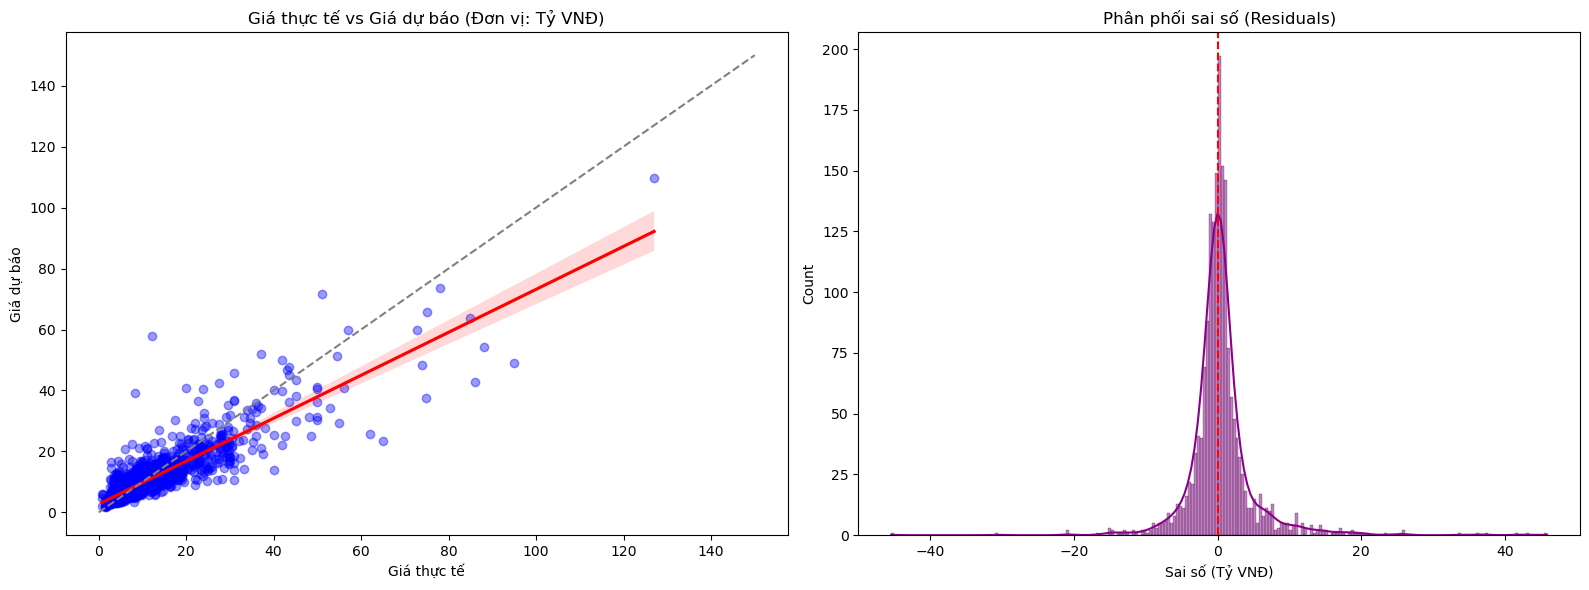

In [21]:
plt.figure(figsize=(16, 6))

# Biểu đồ 1: Thực tế vs Dự đoán
plt.subplot(1, 2, 1)
sns.regplot(x=y_test_original, y=y_pred_original, scatter_kws={'alpha':0.4, 'color':'blue'}, line_kws={'color':'red'})
plt.plot([0, 150], [0, 150], '--', color='gray') # Đường lý tưởng
plt.title("Giá thực tế vs Giá dự báo (Đơn vị: Tỷ VNĐ)")
plt.xlabel("Giá thực tế")
plt.ylabel("Giá dự báo")

# Biểu đồ 2: Phân phối phần dư (Residuals)
plt.subplot(1, 2, 2)
residuals = y_test_original - y_pred_original
sns.histplot(residuals, kde=True, color='darkmagenta')
plt.axvline(0, color='red', linestyle='--')
plt.title("Phân phối sai số (Residuals)")
plt.xlabel("Sai số (Tỷ VNĐ)")

plt.tight_layout()
plt.show()

# 6. Đánh giá kết luận

1. **Hiệu suất dự báo:** Mô hình đạt R2 = 0.7502 và MAE = 2.6 tỷ VNĐ. Đây là kết quả khả quan hơn model baseline, cho thấy mô hình nắm bắt được quy luật định giá của 75% thị trường bất động sản dân dụng trong bộ dữ liệu.

2. **Phân tích giới hạn của chỉ số R2:** 
Tôi nghĩ chỉ số R2 khó có thể đẩy cao hơn sau nhiều lần thử nghiệm do những rào cản từ đặc thù dữ liệu:
* **Thiếu  một số đặc trưng then chốt:** Các yếu tố cực kỳ quan trọng như "nhà mặt tiền", "độ rộng hẻm", "hướng nhà" hay "chất lượng nội thất" xuất hiện không đồng nhất trong tin đăng thô, khiến nhóm không thể trích xuất toàn diện cho toàn bộ 9.116 mẫu. Từ đó, khiến việc nắm bắt quy luật giá nhà từ bộ dữ liệu trên khó đạt độ hoàn hảo cao hơn.
* **Biến số định tính:** Giá bất động sản thực tế còn bị chi phối bởi các yếu tố phong thủy, tâm lý chủ nhà và tình trạng xuống cấp của công trình - những thông tin mà các biến số vật lý hiện có không thể bao hàm hết. Hay thậm chí là có những nhà bị rao bán với giá 'ảo', khiến khó nắm được quy luật hơn.

3. **Đánh giá trực quan qua biểu đồ:**
* **Giá thực tế vs Dự báo:** Các điểm dữ liệu bám sát đường lý tưởng (y=x) ở phân khúc nhà phổ thông (dưới 40 tỷ). Với các bất động sản giá trị cao (>60 tỷ), đường hồi quy thực tế (màu đỏ) có xu hướng lệch xuống dưới, cho thấy mô hình dự báo thấp hơn thực tế.
* **Phân phối phần dư:** Sai số tập trung nhiều tại mốc 0 và tạo thành hình quả chuông đối xứng. Điều này cho thấy mô hình đạt độ ổn định tương đối cao, hoàn toàn có thể tin cậy trong phạm vi các đặc trưng hiện có. Nhưng trong đó, cũng có một vài điểm dữ liệu dự đoán có phần dư lớn, có thể là nhiễu hoặc những trường hợp đặc biệt mà mô hình chưa nắm bắt được quy luật do chưa khai thác đủ đặc trưng.